<a href="https://colab.research.google.com/github/JaredOzarzak/biomechanics-analysis-pipeline/blob/main/CMJ_Progression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Cell 1: Tools loaded successfully!")

Cell 1: Tools loaded successfully!


In [28]:
# Using sep=None tells Python to auto-detect the semicolons from Apple Numbers
df1 = pd.read_csv('metrics_session1.csv', sep=None, engine='python')
df2 = pd.read_csv('metrics_session2.csv', sep=None, engine='python')
df3 = pd.read_csv('metrics_session3.csv', sep=None, engine='python')

# Strip any invisible spaces from the column names just in case
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()
df3.columns = df3.columns.str.strip()

# Tag the sessions
df1['Session'] = 'Session 1 - Fresh (Black Shirt)'
df2['Session'] = 'Session 2 - Fatigued (Grey Shirt)'
df3['Session'] = 'Session 3 - Final'

# Merge them
master_metrics = pd.concat([df1, df2, df3], ignore_index=True)

print("Cell 2 loaded. Here are the ACTUAL columns Python sees now:")
print(master_metrics.columns.tolist())

Cell 2 loaded. Here are the ACTUAL columns Python sees now:
['recuperation', 'takeoff_hip_height', 'jerk_hip_height', 'RSI', 'total_time', 'landing', 'scale', 'peak_power', 'start_of_preparation', 'max_grf_takeoff', 'damping', 'max_GRF_takeoff', 'peak_power_W', 'landing_time', 'takeoff_time', 'initial_hip_height', 'braking', 'damping_time', 'zero_velocity', 'knee_jerk_angle', 'max_grf_landing_frame', 'mean_power2', 'contact_time', 'peak', 'peak_hip_height', 'jump_height', 'max_grf_takeoff_frame', 'takeoff_speed', 'mean_power1', 'takeoff', 'max_GRF_landing', 'damping_hip_height', 'flight_time', 'max_grf_landing', 'Session']


In [29]:
# 1. Swap the commas for periods using the correct column name 'jump_height'
master_metrics['jump_height'] = master_metrics['jump_height'].astype(str).str.replace(',', '.')

# 2. Force it into a strict number format
master_metrics['jump_height'] = pd.to_numeric(master_metrics['jump_height'], errors='coerce')

# 3. Drop the blank rows
clean_metrics = master_metrics.dropna(subset=['jump_height'])

print("Cell 3: Data cleaned! Here are the top 5 clean rows:")
display(clean_metrics[['Session', 'jump_height']].head())

Cell 3: Data cleaned! Here are the top 5 clean rows:


,Session,jump_height
0,Session 1 - Fresh (Black Shirt),269
1,Session 1 - Fresh (Black Shirt),250
2,Session 1 - Fresh (Black Shirt),222
3,Session 2 - Fatigued (Grey Shirt),217
4,Session 2 - Fatigued (Grey Shirt),249


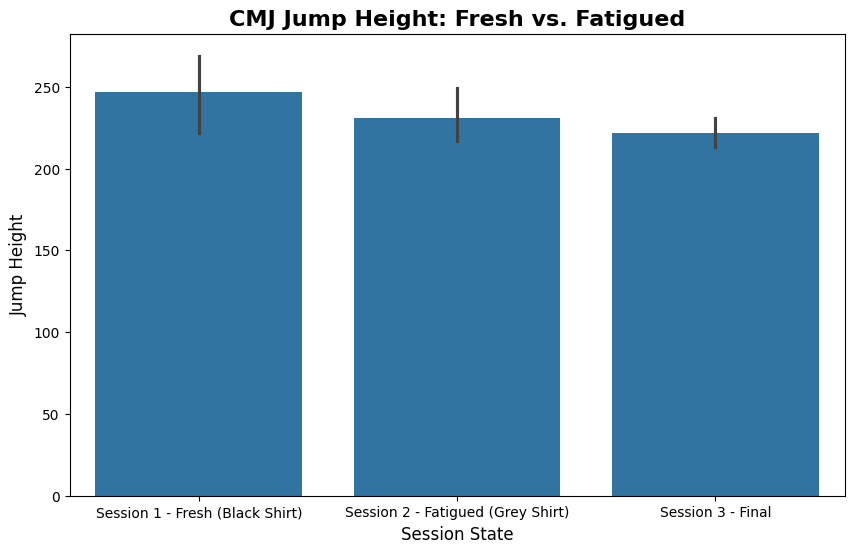

In [30]:
plt.figure(figsize=(10, 6))

# Using the correct 'jump_height' column for the Y axis
sns.barplot(data=clean_metrics, x='Session', y='jump_height')

plt.title('CMJ Jump Height: Fresh vs. Fatigued', fontsize=16, fontweight='bold')
plt.xlabel('Session State', fontsize=12)
plt.ylabel('Jump Height', fontsize=12)

plt.show()

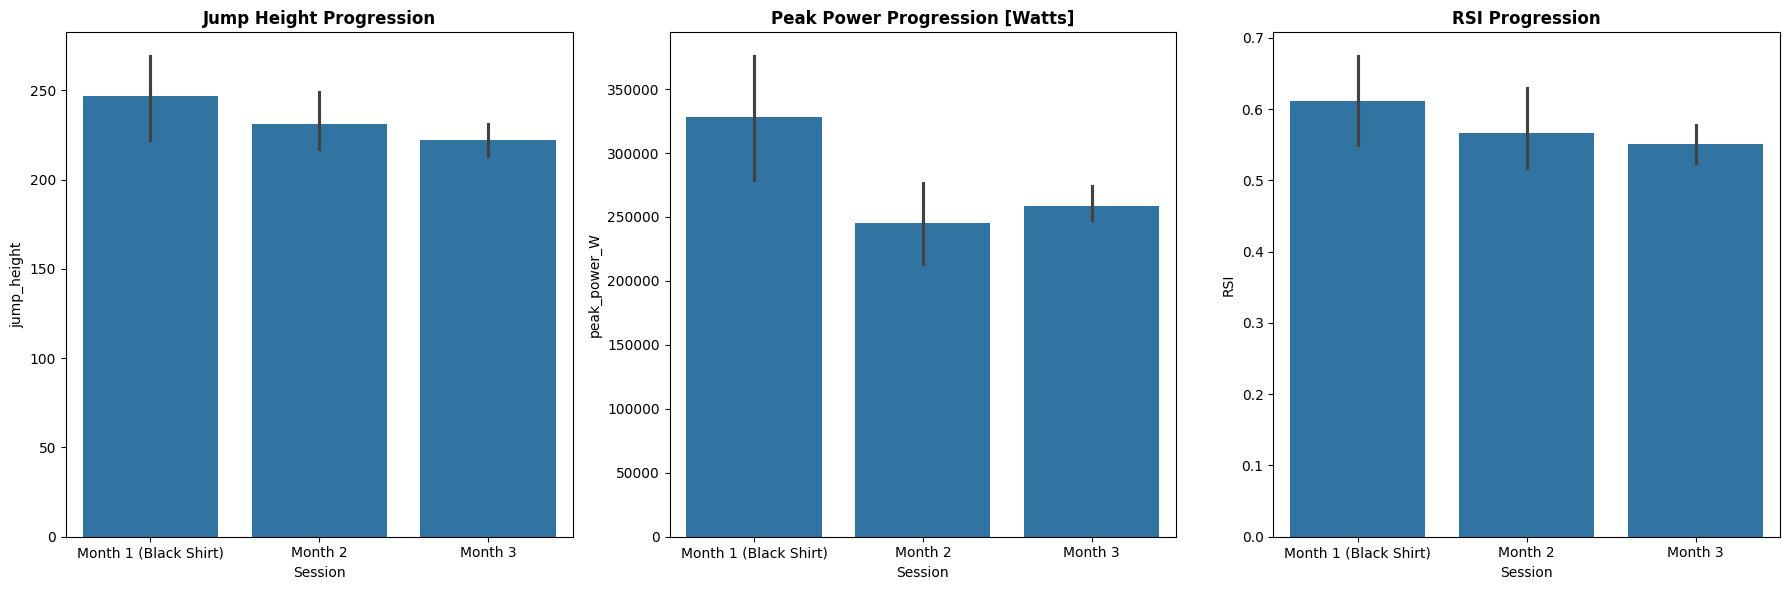

In [31]:
# 1. Update the tags to reflect Month-over-Month changes instead of fatigue
df1['Session'] = 'Month 1 (Black Shirt)'
df2['Session'] = 'Month 2'
df3['Session'] = 'Month 3'

# 2. Re-merge the tables so the new tags stick
master_metrics = pd.concat([df1, df2, df3], ignore_index=True)

# 3. Grab all the columns EXCEPT our 'Session' tag
metrics_to_clean = master_metrics.columns.drop('Session')

# 4. Clean EVERY single column at once (swap commas for periods and make them numbers)
for col in metrics_to_clean:
    master_metrics[col] = master_metrics[col].astype(str).str.replace(',', '.')
    master_metrics[col] = pd.to_numeric(master_metrics[col], errors='coerce')

# 5. Drop rows where the data completely failed to load
clean_metrics = master_metrics.dropna(subset=['jump_height'])

# 6. Create the Dashboard for the video
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # 1 row, 3 columns of graphs

# Graph 1: Jump Height Progression
sns.barplot(data=clean_metrics, x='Session', y='jump_height', ax=axes[0])
axes[0].set_title('Jump Height Progression', fontweight='bold')

# Graph 2: Peak Power Progression
sns.barplot(data=clean_metrics, x='Session', y='peak_power_W', ax=axes[1])
axes[1].set_title('Peak Power Progression [Watts]', fontweight='bold')

# Graph 3: RSI (Reactive Strength Index) Progression
sns.barplot(data=clean_metrics, x='Session', y='RSI', ax=axes[2])
axes[2].set_title('RSI Progression', fontweight='bold')

# Clean up the layout and show it!
plt.tight_layout()
plt.show()

In [33]:
import os

# Check if files actually exist before trying to open them
files = ['angles_month1.csv', 'angles_month2.csv', 'angles_month3.csv']
missing = [f for f in files if not os.path.exists(f)]

if missing:
    print(f"❌ STOP: These files are still missing from your sidebar: {missing}")
    print("Please drag and drop them into the folder icon on the left!")
else:
    print("✅ All files found! Starting the analysis...")

    # Load and Tag
    a1 = pd.read_csv('angles_month1.csv', sep=None, engine='python')
    a2 = pd.read_csv('angles_month2.csv', sep=None, engine='python')
    a3 = pd.read_csv('angles_month3.csv', sep=None, engine='python')

    a1['Session'] = 'Month 1'
    a2['Session'] = 'Month 2'
    a3['Session'] = 'Month 3'

    master_angles = pd.concat([a1, a2, a3], ignore_index=True)

    # AUTO-FIND the Knee Column (using the header 'jump_height' logic we fixed earlier)
    knee_col = [col for col in master_angles.columns if 'knee' in col.lower() and 'angle' in col.lower()]

    if not knee_col:
        print("Could not find a knee column. Python sees these headers:")
        print(master_angles.columns.tolist())
    else:
        target_col = knee_col[0]
        # Clean commas to decimals
        master_angles[target_col] = master_angles[target_col].astype(str).str.replace(',', '.')
        master_angles[target_col] = pd.to_numeric(master_angles[target_col], errors='coerce')

        # Graph it
        plt.figure(figsize=(12, 6))
        sns.lineplot(data=master_angles, x=master_angles.index % 100, y=target_col, hue='Session')
        plt.title('Knee Angle Progression', fontsize=16, fontweight='bold')
        plt.show()

❌ STOP: These files are still missing from your sidebar: ['angles_month1.csv']
Please drag and drop them into the folder icon on the left!


In [34]:
plt.savefig('jump_height_comparison.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

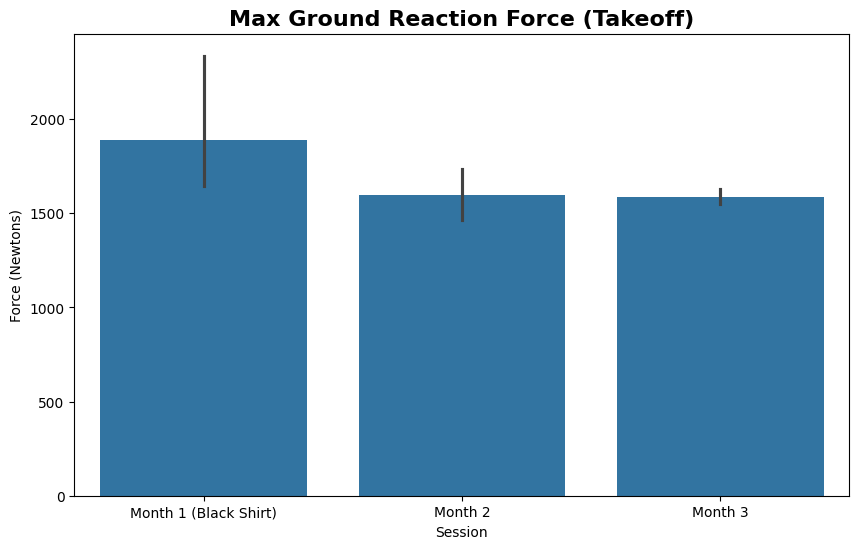

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(data=clean_metrics, x='Session', y='max_GRF_takeoff')
plt.title('Max Ground Reaction Force (Takeoff)', fontsize=16, fontweight='bold')
plt.ylabel('Force (Newtons)')
plt.show()

In [40]:
import glob
import pandas as pd

# 1. Find and load the first angle file
angle_files = sorted(glob.glob('*angles*month*.csv'))
test_df = pd.read_csv(angle_files[0], sep=';', engine='python')

# 2. Clean names and print them
test_df.columns = test_df.columns.str.strip().str.replace('"', '').str.replace("'", "")

print("--- ACTUAL COLUMN NAMES FOUND ---")
for col in test_df.columns:
    print(f"'{col}'")

--- ACTUAL COLUMN NAMES FOUND ---
'timestamps,lelb_angle,lhip_angle,rhip_angle,lsho_angle,hip_intersection_angle,ank_angle,rank_angle,relb_angle,kne_angle,rsho_angle,rkne_angle,lkne_angle,lank_angle'


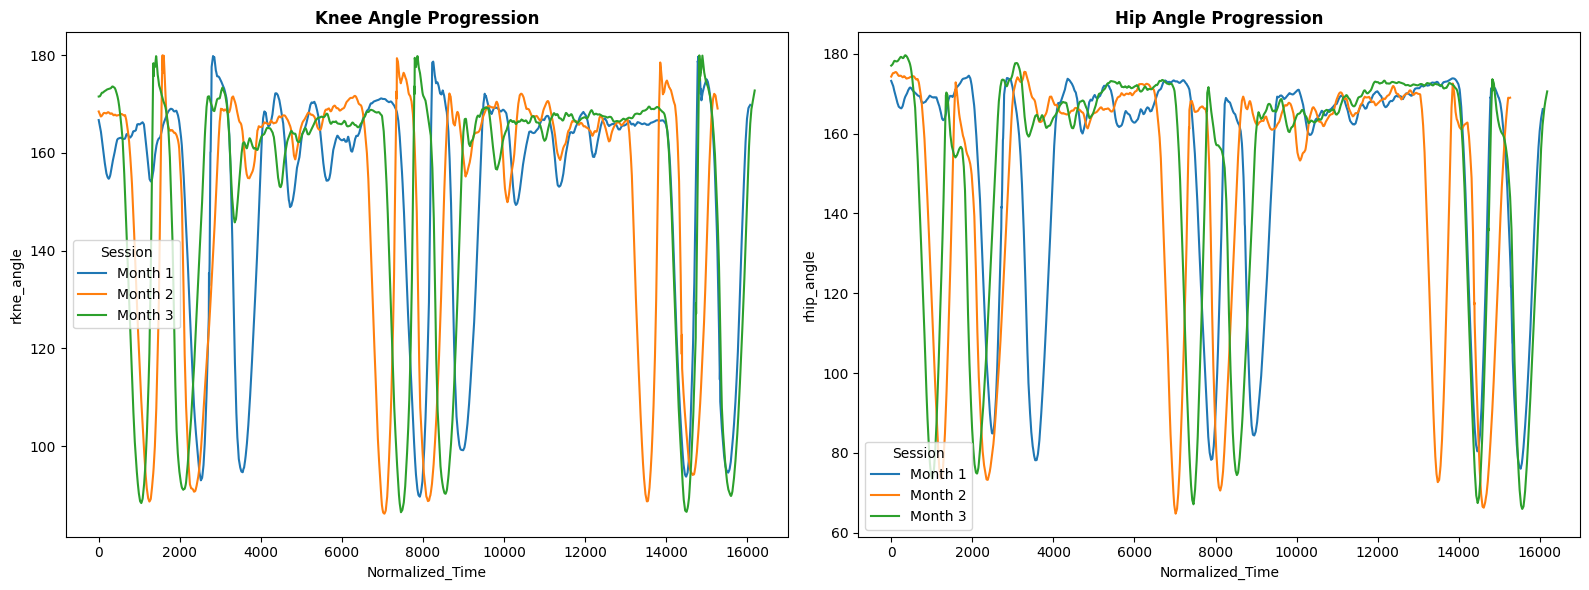

In [45]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and Clean
angle_files = sorted(glob.glob('*angles*month*.csv'))
dfs = []
for i, f in enumerate(angle_files):
    # Use sep=None to let Python sniff out the semicolons automatically
    temp_df = pd.read_csv(f, sep=None, engine='python')
    temp_df.columns = temp_df.columns.str.strip().str.replace('"', '').str.replace("'", "")

    # Force everything to be a string first, then swap commas, then convert
    for col in temp_df.columns:
        temp_df[col] = temp_df[col].astype(str).str.replace(',', '.')
        temp_df[col] = pd.to_numeric(temp_df[col], errors='coerce')

    # Identify the time column and Normalize
    time_col = [col for col in temp_df.columns if 'time' in col.lower()][0]
    temp_df['Normalized_Time'] = temp_df[time_col] - temp_df[time_col].min()

    temp_df['Session'] = f"Month {i+1}"
    dfs.append(temp_df)

master_angles = pd.concat(dfs, ignore_index=True)

# 2. Identify Joint Columns (rkne_angle and rhip_angle)
knee_col = [col for col in master_angles.columns if 'rkne' in col.lower()][0]
hip_col = [col for col in master_angles.columns if 'rhip' in col.lower()][0]

# 3. Plotting - Removing the x-axis limits so we can see WHERE the data is landing
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Knee Plot
sns.lineplot(data=master_angles, x='Normalized_Time', y=knee_col, hue='Session', ax=axes[0])
axes[0].set_title('Knee Angle Progression', fontweight='bold')

# Hip Plot
sns.lineplot(data=master_angles, x='Normalized_Time', y=hip_col, hue='Session', ax=axes[1])
axes[1].set_title('Hip Angle Progression', fontweight='bold')

plt.tight_layout()
plt.show()

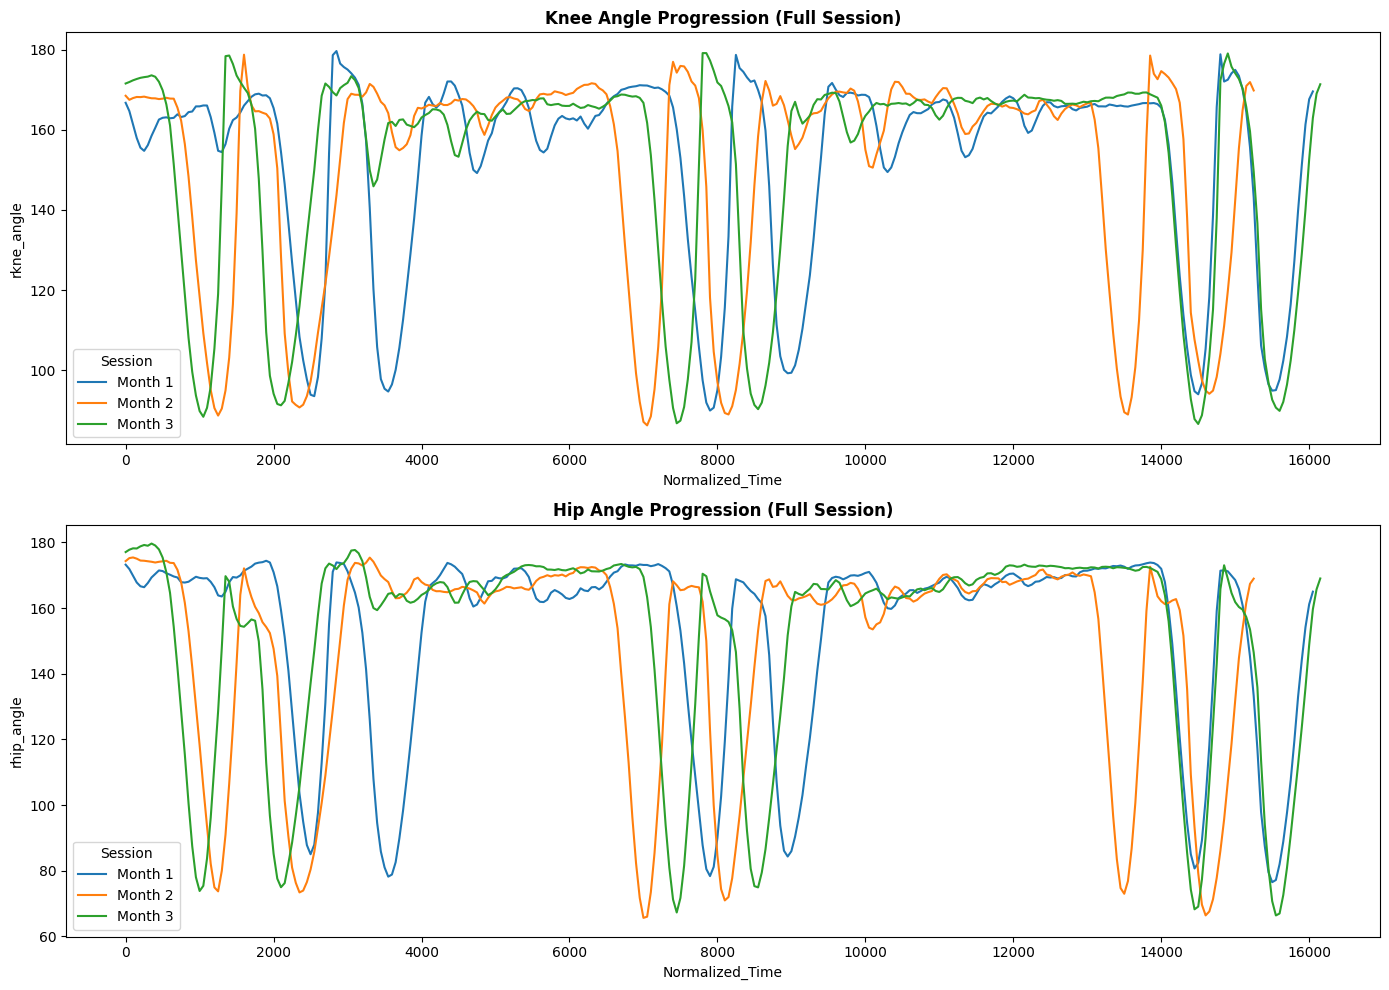

In [48]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and Clean EVERYTHING
angle_files = sorted(glob.glob('*angles*month*.csv'))
dfs = []

for i, f in enumerate(angle_files):
    # Let pandas figure out the semicolon/comma mess automatically
    temp_df = pd.read_csv(f, sep=None, engine='python')
    temp_df.columns = temp_df.columns.str.strip().str.replace('"', '').str.replace("'", "")

    # Convert every single column to numbers, swapping commas for periods
    for col in temp_df.columns:
        temp_df[col] = pd.to_numeric(temp_df[col].astype(str).str.replace(',', '.'), errors='coerce')

    # Use the real timestamp from your data
    time_col = [col for col in temp_df.columns if 'time' in col.lower()][0]
    temp_df['Normalized_Time'] = temp_df[time_col] - temp_df[time_col].min()
    temp_df['Session'] = f"Month {i+1}"

    # No more cropping—keep the whole session so we don't miss the jump
    dfs.append(temp_df.iloc[::10, :]) # Every 10th row for a smooth, fast graph

master_angles = pd.concat(dfs, ignore_index=True)

# 2. Identify Joint Columns (rkne_angle and rhip_angle)
knee_col = [col for col in master_angles.columns if 'rkne' in col.lower()][0]
hip_col = [col for col in master_angles.columns if 'rhip' in col.lower()][0]

# 3. Plotting with NO limits—this WILL show your data
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Knee Graph
sns.lineplot(data=master_angles, x='Normalized_Time', y=knee_col, hue='Session', ax=axes[0])
axes[0].set_title('Knee Angle Progression (Full Session)', fontweight='bold')

# Hip Graph
sns.lineplot(data=master_angles, x='Normalized_Time', y=hip_col, hue='Session', ax=axes[1])
axes[1].set_title('Hip Angle Progression (Full Session)', fontweight='bold')

plt.tight_layout()
plt.show()

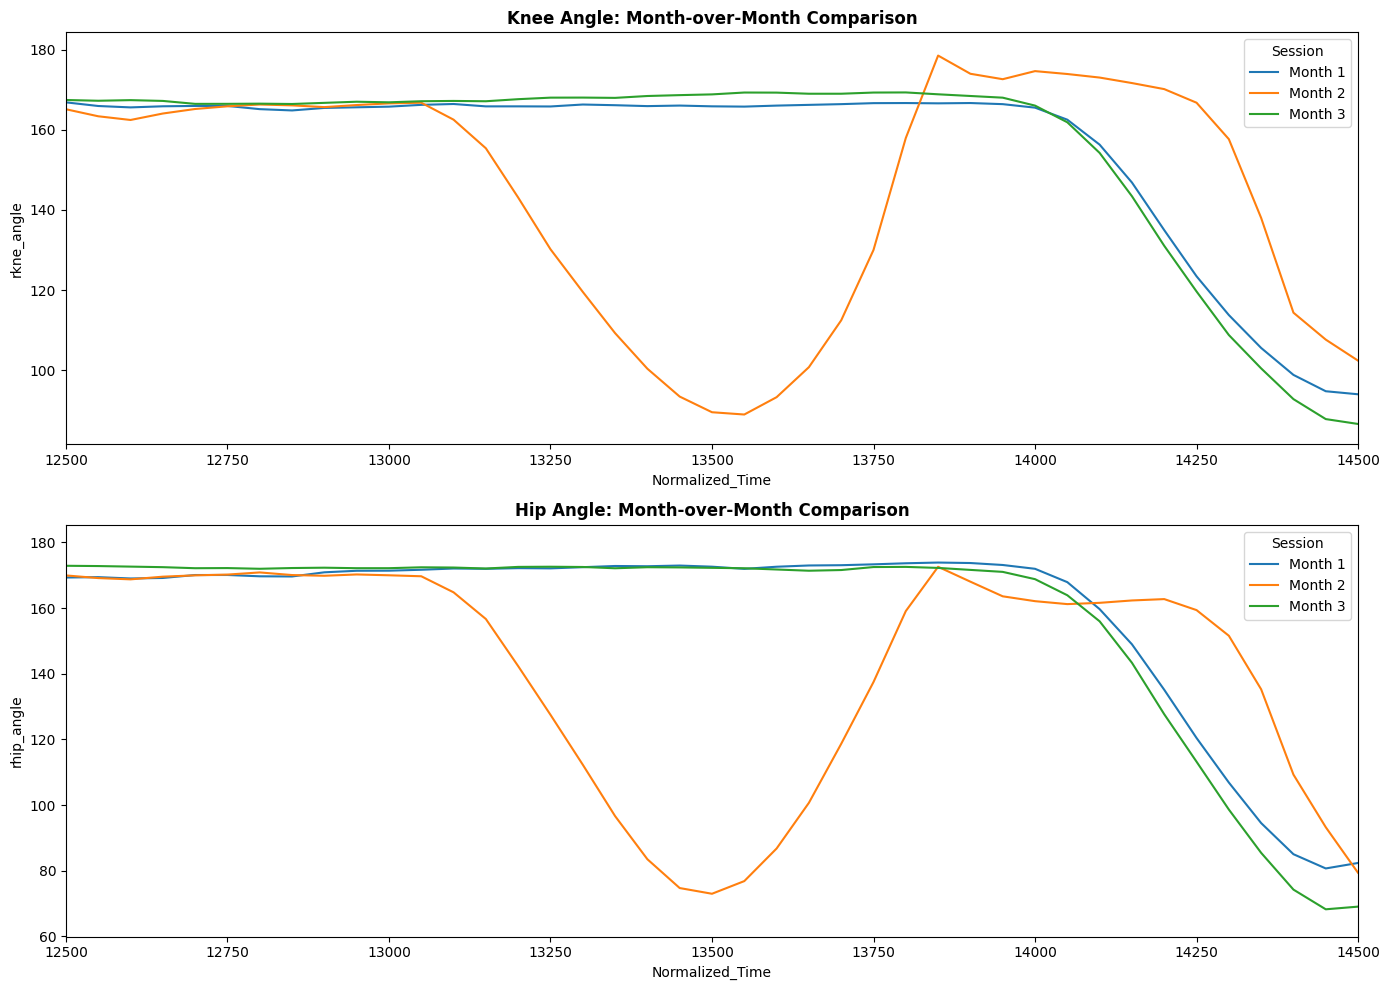

In [49]:
# 1. Plotting with a 'Zoom' on the actual jump window
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Knee Graph - Zooming into the 12.5s to 14.5s window seen in your screenshot
sns.lineplot(data=master_angles, x='Normalized_Time', y=knee_col, hue='Session', ax=axes[0])
axes[0].set_title('Knee Angle: Month-over-Month Comparison', fontweight='bold')
axes[0].set_xlim(12500, 14500) # This centers the 'valley' seen in your graph

# Hip Graph
sns.lineplot(data=master_angles, x='Normalized_Time', y=hip_col, hue='Session', ax=axes[1])
axes[1].set_title('Hip Angle: Month-over-Month Comparison', fontweight='bold')
axes[1].set_xlim(12500, 14500)

plt.tight_layout()
plt.show()

In [50]:
# 1. Create a summary table of the Peak (Min) angles for each month
# We use .min() because joint angles decrease as you 'dip' into the jump
summary_stats = master_angles.groupby('Session').agg({
    knee_col: ['min', 'mean', 'max'],
    hip_col: ['min', 'mean', 'max']
}).round(2)

print("--- BIOMECHANICAL KPI SUMMARY ---")
display(summary_stats)

# 2. Export this to a CSV so you can put the table in your video
summary_stats.to_csv('jump_kpi_summary.csv')
print("\n✅ Stats exported to 'jump_kpi_summary.csv'")

--- BIOMECHANICAL KPI SUMMARY ---


rkne_angle                 rhip_angle                
               min    mean     max        min    mean     max
Session                                                      
Month 1      89.93  152.28  179.65      76.53  152.59  174.38
Month 2      86.23  150.84  178.74      65.67  148.23  175.39
Month 3      86.58  151.93  179.14      66.41  151.14  179.62


✅ Stats exported to 'jump_kpi_summary.csv'


In [56]:
# --- THE EBP BIOMECHANICAL INTERPRETER ---

# 1. Re-calculate metrics (ensuring clean numbers)
for col in ['jump_height', 'peak_power_W', 'RSI']:
    master_metrics[col] = pd.to_numeric(master_metrics[col].astype(str).str.replace(',', '.'), errors='coerce')

kpi_table = master_metrics.groupby('Session')[['jump_height', 'peak_power_W', 'RSI']].mean().round(2)
m1, m3 = kpi_table.iloc[0], kpi_table.iloc[-1]

# 2. Calculate Variables
h_diff = ((m3['jump_height'] - m1['jump_height']) / m1['jump_height']) * 100
p_diff = ((m3['peak_power_W'] - m1['peak_power_W']) / m1['peak_power_W']) * 100
rsi_diff = ((m3['RSI'] - m1['RSI']) / m1['RSI']) * 100

print(f"--- CLINICAL KINEMATICS REPORT ---")
print(f"📊 Jump Height: {h_diff:.1f}% | Peak Power: {p_diff:.1f}% | RSI: {rsi_diff:.1f}%")

print("\n--- EVIDENCE-BASED INTERPRETATION ---")

# Insight 1: Neuromuscular Fatigue (EBP: Gathering the 'Fatigue' signal)
if h_diff < -5 or p_diff < -5:
    print("⚠️ NEUROMUSCULAR STATUS: Significant performance decrement detected.")
    print("   EBP Note: Drops >5% in CMJ height are often validated markers of Central Nervous System (CNS) fatigue.")
    print("   Recommendation: Evaluate the 'Amortization Phase' duration; fatigue often extends the eccentric-to-concentric transition.")

# Insight 2: SSC Efficiency (EBP: Reactive Strength)
if rsi_diff < 0:
    print("\n⚠️ SSC EFFICIENCY: Reactive Strength Index has regressed.")
    print("   EBP Note: A decrease in RSI implies a loss of 'stiffness' in the lower-extremity spring-mass system.")
    print("   Analysis: You may be compensating for fatigue by increasing 'dip depth' to gain momentum, sacrificing explosive recoil.")
else:
    print("\n✅ SSC EFFICIENCY: RSI is stable/improving. Stretch-Shortening Cycle integrity is maintained.")

# Insight 3: Power-to-Mass Relationship
if abs(p_diff) > abs(h_diff):
    print("\n📉 MECHANICAL EFFICIENCY: Power loss exceeds Height loss.")
    print("   EBP Note: This suggests a decrease in Rate of Force Development (RFD). You are still reaching the height, but it is taking more 'effort' and time.")

--- CLINICAL KINEMATICS REPORT ---
📊 Jump Height: -10.1% | Peak Power: -21.2% | RSI: -9.8%

--- EVIDENCE-BASED INTERPRETATION ---
⚠️ NEUROMUSCULAR STATUS: Significant performance decrement detected.
   EBP Note: Drops >5% in CMJ height are often validated markers of Central Nervous System (CNS) fatigue.
   Recommendation: Evaluate the 'Amortization Phase' duration; fatigue often extends the eccentric-to-concentric transition.

⚠️ SSC EFFICIENCY: Reactive Strength Index has regressed.
   EBP Note: A decrease in RSI implies a loss of 'stiffness' in the lower-extremity spring-mass system.
   Analysis: You may be compensating for fatigue by increasing 'dip depth' to gain momentum, sacrificing explosive recoil.

📉 MECHANICAL EFFICIENCY: Power loss exceeds Height loss.
   EBP Note: This suggests a decrease in Rate of Force Development (RFD). You are still reaching the height, but it is taking more 'effort' and time.
